# Notebook 02 -- Feature Engineering & Hierarchy Exploitation

**Dataset**: FreshRetailNet-50K (fresh grocery retail demand forecasting)  
**Objective**: Build a comprehensive feature engineering pipeline for demand forecasting, covering temporal features, lag features, rolling statistics, stockout history, cross/interaction features, and hierarchical aggregation.

This notebook is **educational** -- every feature group includes an explanation of *why* it helps and *what pitfalls* to watch for.

---

**Sections**:
1. Setup & Data Loading
2. Temporal Features
3. Lag Features
4. Rolling Statistics
5. Stockout History Features
6. Cross & Interaction Features
7. Hierarchy Exploitation (Educational Core)
8. Feature Summary

---
## 1. Setup & Data Loading

We load the FreshRetailNet-50K dataset, sample 3000 store-product (SP) combinations stratified by stockout rate (so we get a mix of heavily-censored and clean series), add a simple demand recovery estimate, and create a unique SP identifier.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, gc

%matplotlib inline

import os
NB_OUT = os.path.join('..', 'notebook_output')
os.makedirs(NB_OUT, exist_ok=True)
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')
np.random.seed(42)

# Plotting defaults
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Data paths (relative to notebooks/) ──────────────────────────────────────
TRAIN_PATH = '../../data/freshretailnet/raw/data/train.parquet'
EVAL_PATH  = '../../data/freshretailnet/raw/data/eval.parquet'

N_SP = 3000   # number of store-product combos to sample

# Columns we need
COLS = [
    'city_id', 'store_id', 'management_group_id',
    'first_category_id', 'second_category_id', 'third_category_id',
    'product_id', 'dt',
    'sale_amount', 'stock_hour6_22_cnt',
    'discount', 'holiday_flag', 'activity_flag',
    'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level',
]

train_raw = pd.read_parquet(TRAIN_PATH, columns=COLS)
eval_raw  = pd.read_parquet(EVAL_PATH, columns=COLS)

print(f'Train raw shape: {train_raw.shape}')
print(f'Eval  raw shape: {eval_raw.shape}')
print(f'Train dates: {train_raw["dt"].min()} -> {train_raw["dt"].max()}')
print(f'Eval  dates: {eval_raw["dt"].min()} -> {eval_raw["dt"].max()}')

Train raw shape: (4500000, 17)
Eval  raw shape: (350000, 17)
Train dates: 2024-03-28 -> 2024-06-25
Eval  dates: 2024-06-26 -> 2024-07-02


### 1.1 Stratified Sampling by Stockout Rate

We want a representative mix of SPs: some with almost no stockouts, some with moderate stockout rates, and some with heavy censoring. We bin SPs into 5 quantile groups by their stockout rate and sample equally from each bin.

In [3]:
# Create SP identifier: store_id * 10000 + product_id
train_raw['sp'] = train_raw['store_id'] * 10000 + train_raw['product_id']
eval_raw['sp']  = eval_raw['store_id'] * 10000 + eval_raw['product_id']

# Compute stockout rate per SP
so_rate = train_raw.groupby('sp')['stock_hour6_22_cnt'].apply(lambda x: (x > 0).mean())
so_rate = so_rate.reset_index()
so_rate.columns = ['sp', 'stockout_rate']

# Stratified bins
so_rate['bin'] = pd.qcut(so_rate['stockout_rate'], q=5, labels=False, duplicates='drop')

# Sample equally from each bin
per_bin = N_SP // so_rate['bin'].nunique()
sampled_sps = (
    so_rate
    .groupby('bin', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), per_bin), random_state=42))
)['sp'].values

# Top-up if we didn't reach N_SP
if len(sampled_sps) < N_SP:
    remaining = np.setdiff1d(so_rate['sp'].values, sampled_sps)
    extra = np.random.choice(remaining, N_SP - len(sampled_sps), replace=False)
    sampled_sps = np.concatenate([sampled_sps, extra])

sampled_sps = set(sampled_sps[:N_SP])
print(f'Sampled {len(sampled_sps)} SPs')
print(f'Stockout rate distribution of sampled SPs:')
print(so_rate[so_rate['sp'].isin(sampled_sps)]['stockout_rate'].describe())

Sampled 3000 SPs
Stockout rate distribution of sampled SPs:
count    3000.000000
mean        0.445548
std         0.147382
min         0.122222
25%         0.344444
50%         0.422222
75%         0.522222
max         1.000000
Name: stockout_rate, dtype: float64


In [4]:
# Filter to sampled SPs
train = train_raw[train_raw['sp'].isin(sampled_sps)].copy()
ev    = eval_raw[eval_raw['sp'].isin(sampled_sps)].copy()

train['dt'] = pd.to_datetime(train['dt'])
ev['dt']    = pd.to_datetime(ev['dt'])

# Downcast for memory efficiency
for c in train.select_dtypes('int64').columns:
    if c != 'sp':
        train[c] = train[c].astype('int32')
        ev[c]    = ev[c].astype('int32')
for c in train.select_dtypes('float64').columns:
    train[c] = train[c].astype('float32')
    ev[c]    = ev[c].astype('float32')

print(f'Train: {train.shape}  |  Eval: {ev.shape}')
print(f'Memory: {train.memory_usage(deep=True).sum()/1e6:.1f} MB')

# Free raw data
del train_raw, eval_raw, so_rate
gc.collect()

train.head()

Train: (270000, 18)  |  Eval: (21000, 18)
Memory: 23.8 MB


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,sp
270,0,0,2,0,21,221,686,2024-03-28,0.4,0,0.882,0,1,1.6999,15.480000,73.540001,1.97,686
271,0,0,2,0,21,221,686,2024-03-29,0.4,4,0.882,0,1,3.0190,15.080000,76.559998,1.71,686
272,0,0,2,0,21,221,686,2024-03-30,0.7,0,0.882,1,1,2.0942,15.910000,76.470001,1.73,686
273,0,0,2,0,21,221,686,2024-03-31,0.9,4,0.882,1,1,1.5618,16.129999,77.400002,1.76,686
274,0,0,2,0,21,221,686,2024-04-01,0.4,0,0.882,0,1,3.5386,15.370000,78.260002,1.25,686


### 1.2 Simple Demand Recovery (Proportional Method)

When a product is out of stock for part of the day, observed sales undercount true demand. We use a simple proportional adjustment:

- **Partial stockout** (0 < stockout_hours < 16): Scale up sales by the fraction of hours the product was available. If a product was available for 10 out of 16 operating hours, multiply sales by 16/10.
- **Full stockout** (stockout_hours >= 16): Use the rolling average of non-censored days as the demand estimate.

This is deliberately simple for this notebook. More sophisticated methods (EM, Tobit, Bayesian) exist and may be covered elsewhere.

In [5]:
OP_HOURS = 16  # operating hours: 6am to 10pm

df = train.sort_values(['sp', 'dt']).reset_index(drop=True)

# Censoring indicator
df['cens'] = (df['stock_hour6_22_cnt'] > 0).astype('int8')
df['so_frac'] = (df['stock_hour6_22_cnt'] / OP_HOURS).astype('float32')

# Start with observed sales (use float64 to avoid dtype mismatch during computation)
df['dem_rec'] = df['sale_amount'].values.copy().astype(np.float64)

# ── Partial stockout: proportional scale-up ─────────────────────────────────
partial = (df['stock_hour6_22_cnt'] > 0) & (df['stock_hour6_22_cnt'] < OP_HOURS)
avail_hours = (OP_HOURS - df['stock_hour6_22_cnt']).clip(lower=1)
df.loc[partial, 'dem_rec'] = df.loc[partial, 'sale_amount'] * (OP_HOURS / avail_hours[partial])

# ── Full stockout: use rolling average of non-censored days ──────────────────
full_so = df['stock_hour6_22_cnt'] >= OP_HOURS
non_cens_flag = (df['cens'] == 0).astype(float)
df['_non_cens_sales'] = df['sale_amount'] * non_cens_flag

g = df.groupby('sp')
rolling_sales_sum = g['_non_cens_sales'].transform(lambda x: x.rolling(14, min_periods=1).sum())
rolling_count     = g.apply(lambda grp: non_cens_flag.loc[grp.index].rolling(14, min_periods=1).sum())
rolling_count     = rolling_count.reset_index(level=0, drop=True).sort_index().clip(lower=1)
avg_non_stockout  = rolling_sales_sum / rolling_count

df.loc[full_so, 'dem_rec'] = avg_non_stockout[full_so]
df['dem_rec'] = df['dem_rec'].clip(lower=0).astype('float32')

df.drop('_non_cens_sales', axis=1, inplace=True)
del rolling_sales_sum, rolling_count, avg_non_stockout; gc.collect()

print(f'Censored rows:       {df["cens"].sum():,} ({df["cens"].mean()*100:.1f}%)')
print(f'Mean observed sales:  {df["sale_amount"].mean():.4f}')
print(f'Mean recovered demand:{df["dem_rec"].mean():.4f}')
print(f'Recovery uplift:      {(df["dem_rec"].mean() / df["sale_amount"].mean() - 1)*100:.1f}%')

Censored rows:       120,298 (44.6%)
Mean observed sales:  0.9975
Mean recovered demand:1.3975
Recovery uplift:      40.1%


---
## 2. Temporal Features

Time-based features capture **seasonality patterns** in demand:
- Day of week (dow), day of month (dom), week of year (woy), month
- Weekend flag
- **Cyclical encoding** using sin/cos transforms

### Why Cyclical Encoding?

Consider day-of-week encoded as an integer: Monday=0, Tuesday=1, ..., Sunday=6. A tree-based model sees Monday (0) and Sunday (6) as "far apart" (distance = 6), but in reality they are adjacent days. Cyclical encoding using `sin(2*pi*x/period)` and `cos(2*pi*x/period)` maps the values onto a circle, so the model correctly perceives Monday and Sunday as neighbors.

The same logic applies to month (December is close to January) and day-of-month (the 1st is close to the 31st).

In [6]:
# ── Basic temporal features ──────────────────────────────────────────────────
df['dow']   = df['dt'].dt.dayofweek.astype('int8')       # 0=Monday .. 6=Sunday
df['dom']   = df['dt'].dt.day.astype('int8')              # 1..31
df['woy']   = df['dt'].dt.isocalendar().week.astype('int8')  # 1..52
df['month'] = df['dt'].dt.month.astype('int8')            # 1..12
df['wknd']  = (df['dow'] >= 5).astype('int8')             # 1 if Sat/Sun

# ── Cyclical encoding ────────────────────────────────────────────────────────
for col, period in [('dow', 7), ('dom', 31), ('woy', 52)]:
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / period).astype('float32')
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / period).astype('float32')

temporal_features = ['dow', 'dom', 'woy', 'month', 'wknd',
                     'dow_sin', 'dow_cos', 'dom_sin', 'dom_cos', 'woy_sin', 'woy_cos']

print(f'Temporal features created: {len(temporal_features)}')
df[temporal_features].head(10)

Temporal features created: 11


,dow,dom,woy,month,wknd,dow_sin,dow_cos,dom_sin,dom_cos,woy_sin,woy_cos
0,3,28,13,3,0,0.433884,-0.900969,-5.712682e-01,0.820763,1.000000,-1.608123e-16
1,4,29,13,3,0,-0.433884,-0.900969,-3.943559e-01,0.918958,1.000000,-1.608123e-16
2,5,30,13,3,1,-0.974928,-0.222521,-2.012985e-01,0.979530,1.000000,-1.608123e-16
3,6,31,13,3,1,-0.781832,0.623490,-2.449294e-16,1.000000,1.000000,-1.608123e-16
4,0,1,14,4,0,0.000000,1.000000,2.012985e-01,0.979530,0.992709,-1.205367e-01
5,1,2,14,4,0,0.781832,0.623490,3.943559e-01,0.918958,0.992709,-1.205367e-01
6,2,3,14,4,0,0.974928,-0.222521,5.712682e-01,0.820763,0.992709,-1.205367e-01
7,3,4,14,4,0,0.433884,-0.900969,7.247928e-01,0.688967,0.992709,-1.205367e-01
8,4,5,14,4,0,-0.433884,-0.900969,8.486443e-01,0.528964,0.992709,-1.205367e-01
9,5,6,14,4,1,-0.974928,-0.222521,9.377521e-01,0.347305,0.992709,-1.205367e-01


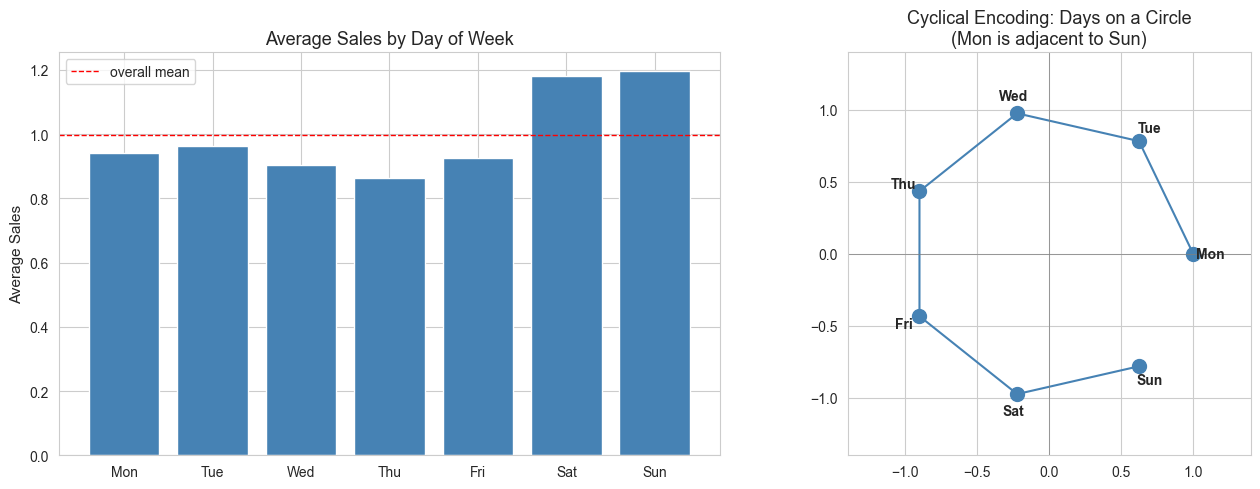

In [7]:
# ── Visualization: Average sales by day of week ─────────────────────────────
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
avg_by_dow = df.groupby('dow')['sale_amount'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(avg_by_dow.index, avg_by_dow.values, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(dow_labels)
axes[0].set_ylabel('Average Sales')
axes[0].set_title('Average Sales by Day of Week')
axes[0].axhline(avg_by_dow.values.mean(), color='red', ls='--', lw=1, label='overall mean')
axes[0].legend()

# Show cyclical encoding on a unit circle
theta = 2 * np.pi * np.arange(7) / 7
axes[1].plot(np.cos(theta), np.sin(theta), 'o-', color='steelblue', ms=10)
for i, label in enumerate(dow_labels):
    axes[1].annotate(label, (np.cos(theta[i])*1.12, np.sin(theta[i])*1.12),
                     ha='center', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlim(-1.4, 1.4); axes[1].set_ylim(-1.4, 1.4)
axes[1].set_aspect('equal')
axes[1].set_title('Cyclical Encoding: Days on a Circle\n(Mon is adjacent to Sun)')
axes[1].axhline(0, color='gray', lw=0.5); axes[1].axvline(0, color='gray', lw=0.5)

plt.tight_layout()
plt.savefig(os.path.join(NB_OUT, 'nb02_temporal_features.png'), dpi=150, bbox_inches='tight')
plt.show()

**Takeaway**: The weekly pattern is clearly visible. Weekend sales tend to differ from weekday sales. Cyclical encoding ensures the model treats Monday-Sunday adjacency correctly.

---
## 3. Lag Features

Lag features give the model access to **recent history** for each SP. The most important feature in demand forecasting is often "what did this product sell yesterday/last week?"

### Data Leakage Warning

We must **shift by at least 1 day** before creating any lag or rolling feature. Without shifting, a "lag-0" feature would contain today's sales -- the very thing we are trying to predict. This is **data leakage** and would give unrealistically good results during training that completely break down in production.

The pattern is: `groupby('sp').shift(lag)` where `lag >= 1`.

### Why Multiple Lags?

- **Lag 1-3**: Capture very recent trends (did demand spike yesterday?)
- **Lag 7**: Captures the same-day-of-week pattern (last Monday predicts this Monday)
- **Lag 14, 21, 28**: Longer-term patterns and monthly cycles
- We create lags for **both** observed sales and recovered demand, since the model can learn from both signals

In [8]:
# Ensure sorted by sp, dt for correct shifting
df = df.sort_values(['sp', 'dt']).reset_index(drop=True)
g = df.groupby('sp')

# ── Lag features for observed sales (s) and recovered demand (r) ─────────────
lag_days = [1, 2, 3, 5, 7, 14, 21, 28]

lag_features = []
for pfx, col in [('s', 'sale_amount'), ('r', 'dem_rec')]:
    for lag in lag_days:
        feat_name = f'{pfx}_lag{lag}'
        df[feat_name] = g[col].shift(lag).astype('float32')
        lag_features.append(feat_name)

print(f'Lag features created: {len(lag_features)}')
print(f'Example features: {lag_features[:6]} ...')

# ── Momentum / difference features ───────────────────────────────────────────
# Day-over-day change: how much did sales change from day before yesterday to yesterday?
df['s_diff1']    = (df['s_lag1'] - df['s_lag2']).astype('float32')
# Week-over-week change: yesterday vs same day last week
df['s_diff7']    = (df['s_lag1'] - df['s_lag7']).astype('float32')
# Recovered demand day-over-day change
df['r_diff1']    = (df['r_lag1'] - df['r_lag2']).astype('float32')

momentum_features = ['s_diff1', 's_diff7', 'r_diff1']
print(f'Momentum features: {momentum_features}')

df[['sp', 'dt', 'sale_amount', 's_lag1', 's_lag7', 's_diff1', 's_diff7']].head(10)

Lag features created: 16
Example features: ['s_lag1', 's_lag2', 's_lag3', 's_lag5', 's_lag7', 's_lag14'] ...
Momentum features: ['s_diff1', 's_diff7', 'r_diff1']


,sp,dt,sale_amount,s_lag1,s_lag7,s_diff1,s_diff7
0,6,2024-03-28,0.5,NaN,NaN,NaN,NaN
1,6,2024-03-29,0.3,0.5,NaN,NaN,NaN
2,6,2024-03-30,0.4,0.3,NaN,-0.2,NaN
3,6,2024-03-31,0.9,0.4,NaN,0.1,NaN
4,6,2024-04-01,0.2,0.9,NaN,0.5,NaN
5,6,2024-04-02,0.3,0.2,NaN,-0.7,NaN
6,6,2024-04-03,0.5,0.3,NaN,0.1,NaN
7,6,2024-04-04,0.8,0.5,0.5,0.2,0.0
8,6,2024-04-05,0.6,0.8,0.3,0.3,0.5
9,6,2024-04-06,0.5,0.6,0.4,-0.2,0.2


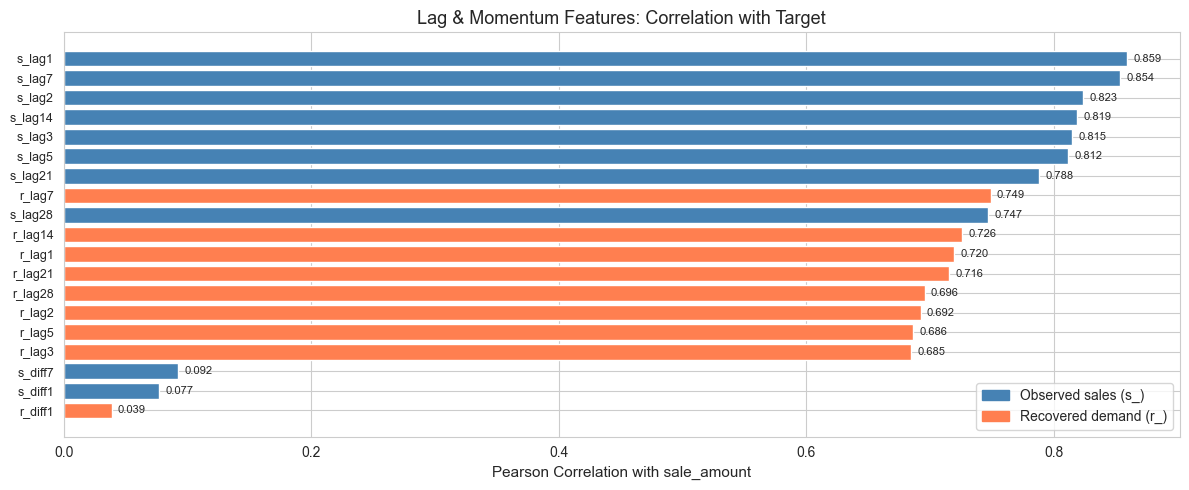

In [9]:
# ── Visualization: Correlation between lags and the target ──────────────────
# Compute correlation of each lag with sale_amount (on non-NaN rows)
all_lag_feats = lag_features + momentum_features
corrs = df[all_lag_feats + ['sale_amount']].corr()['sale_amount'].drop('sale_amount').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue' if 's_' in f else 'coral' for f in corrs.index]
ax.barh(range(len(corrs)), corrs.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(corrs)))
ax.set_yticklabels(corrs.index, fontsize=9)
ax.set_xlabel('Pearson Correlation with sale_amount')
ax.set_title('Lag & Momentum Features: Correlation with Target')
ax.invert_yaxis()

# Add value labels
for i, v in enumerate(corrs.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
ax.legend([Patch(color='steelblue'), Patch(color='coral')],
          ['Observed sales (s_)', 'Recovered demand (r_)'], loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(NB_OUT, 'nb02_lag_momentum_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

**Takeaway**: Lag-1 (yesterday's sales) is typically the strongest single predictor. Lag-7 (same weekday) is also strong due to the weekly pattern. Recovered demand lags provide complementary information, especially for heavily-censored SPs.

---
## 4. Rolling Statistics

While lag features capture specific past values, **rolling statistics** summarize recent behavior over a window:

- **Rolling mean**: Average demand level over the past N days
- **Rolling std**: Demand volatility -- how much does this product fluctuate?
- **Rolling max/min**: Recent peaks and troughs
- **Rolling median**: Robust central tendency (less sensitive to outliers than mean)
- **Quantile features**: 25th/75th percentiles capture the typical range

### Rolling Mean vs EWMA (Exponentially Weighted Moving Average)

- **Rolling mean** treats all days in the window equally: the 7-day rolling mean gives the same weight to 1 day ago and 7 days ago.
- **EWMA** gives **more weight to recent observations** and exponentially decays the weight of older ones. This is often better for demand forecasting because yesterday's sales are more informative than last week's.
- EWMA with `span=7` roughly corresponds to a 7-day window but with exponential weighting.

All rolling features are computed on **shifted** data (shift by 1) to avoid leakage.

In [10]:
# ── Shifted series (avoid leakage) ──────────────────────────────────────────
shifted_s = g['sale_amount'].shift(1)   # observed sales, shifted by 1
shifted_r = g['dem_rec'].shift(1)        # recovered demand, shifted by 1

rolling_features = []

# ── Rolling windows: mean, std, max, min, median ────────────────────────────
for pfx, shifted in [('s', shifted_s), ('r', shifted_r)]:
    for w in [3, 7, 14, 28]:
        r = shifted.groupby(df['sp']).rolling(w, min_periods=1)
        
        # Mean and std for all windows
        feat_mean = f'{pfx}_rmean{w}'
        feat_std  = f'{pfx}_rstd{w}'
        df[feat_mean] = r.mean().reset_index(level=0, drop=True).astype('float32')
        df[feat_std]  = r.std().reset_index(level=0, drop=True).astype('float32')
        rolling_features.extend([feat_mean, feat_std])
        
        # Max, min, median for 7 and 28-day windows
        if w in [7, 28]:
            feat_max = f'{pfx}_rmax{w}'
            feat_min = f'{pfx}_rmin{w}'
            feat_med = f'{pfx}_rmed{w}'
            df[feat_max] = r.max().reset_index(level=0, drop=True).astype('float32')
            df[feat_min] = r.min().reset_index(level=0, drop=True).astype('float32')
            df[feat_med] = r.median().reset_index(level=0, drop=True).astype('float32')
            rolling_features.extend([feat_max, feat_min, feat_med])

print(f'Rolling features (mean/std/max/min/median): {len(rolling_features)}')
gc.collect()

Rolling features (mean/std/max/min/median): 28


27

In [11]:
# ── Quantile features (25th, 75th percentile) ───────────────────────────────
quantile_features = []
for w in [14, 28]:
    r = shifted_s.groupby(df['sp']).rolling(w, min_periods=1)
    feat_q25 = f's_q25_{w}'
    feat_q75 = f's_q75_{w}'
    df[feat_q25] = r.quantile(0.25).reset_index(level=0, drop=True).astype('float32')
    df[feat_q75] = r.quantile(0.75).reset_index(level=0, drop=True).astype('float32')
    quantile_features.extend([feat_q25, feat_q75])

print(f'Quantile features: {quantile_features}')

Quantile features: ['s_q25_14', 's_q75_14', 's_q25_28', 's_q75_28']


In [12]:
# ── EWMA (Exponentially Weighted Moving Average) ────────────────────────────
ewma_features = []
for pfx, shifted in [('s', shifted_s), ('r', shifted_r)]:
    for span in [7, 14]:
        feat_name = f'{pfx}_ewma{span}'
        df[feat_name] = shifted.groupby(df['sp']).transform(
            lambda x: x.ewm(span=span, min_periods=1).mean()
        ).astype('float32')
        ewma_features.append(feat_name)

print(f'EWMA features: {ewma_features}')

# Clean up
del shifted_s, shifted_r
gc.collect()

all_rolling = rolling_features + quantile_features + ewma_features
print(f'\nTotal rolling/EWMA features: {len(all_rolling)}')

EWMA features: ['s_ewma7', 's_ewma14', 'r_ewma7', 'r_ewma14']

Total rolling/EWMA features: 36


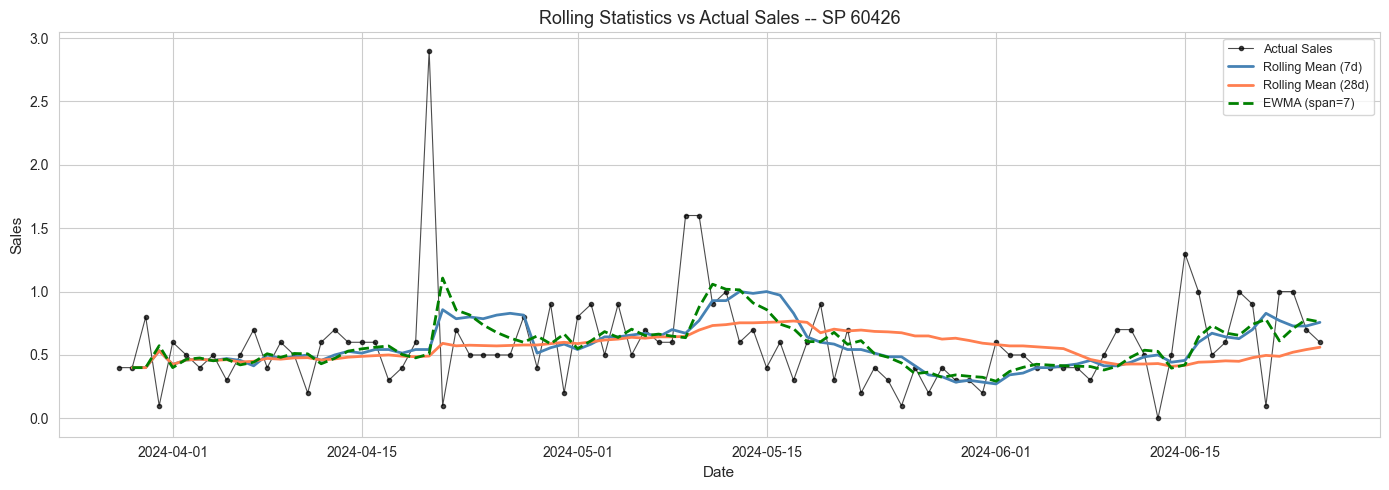

Notice how EWMA (green dashed) reacts faster to recent changes than the rolling mean.


In [13]:
# ── Visualization: Rolling mean vs actual for one example SP ─────────────────
example_sp = df['sp'].unique()[42]  # pick an arbitrary SP
sp_data = df[df['sp'] == example_sp].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sp_data['dt'], sp_data['sale_amount'], 'ko-', ms=3, lw=0.8, label='Actual Sales', alpha=0.7)
ax.plot(sp_data['dt'], sp_data['s_rmean7'], '-', color='steelblue', lw=2, label='Rolling Mean (7d)')
ax.plot(sp_data['dt'], sp_data['s_rmean28'], '-', color='coral', lw=2, label='Rolling Mean (28d)')
ax.plot(sp_data['dt'], sp_data['s_ewma7'], '--', color='green', lw=2, label='EWMA (span=7)')

ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.set_title(f'Rolling Statistics vs Actual Sales -- SP {example_sp}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(NB_OUT, 'nb02_rolling_statistics.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Notice how EWMA (green dashed) reacts faster to recent changes than the rolling mean.')

---
## 5. Stockout History Features

Stockout history is critical for demand forecasting in retail. When a product was recently out of stock, several things may happen:

1. **Substitution effect**: Customers bought alternatives, so demand may be *lower* when the product returns.
2. **Pent-up demand**: Customers waited, so demand *spikes* when the product returns.
3. **Lost customers**: Some customers stopped coming, so baseline demand drops.

By encoding stockout history as features, we let the model learn which pattern applies.

### Features:
- **Lagged censoring indicator** (`so1`, `so7`): Was this SP out of stock yesterday? A week ago?
- **Rolling stockout rate**: Fraction of days with stockouts over the past 7/14 days
- **Rolling average stockout hours**: Severity of recent stockouts
- **CV (Coefficient of Variation)**: Demand volatility relative to mean -- high CV often signals intermittent demand or stockout issues

In [14]:
g = df.groupby('sp')

stockout_features = []

# ── Lagged censoring indicators ──────────────────────────────────────────────
cs = g['cens'].shift(1)  # was there a stockout yesterday?
df['so1'] = cs.astype('float32')                      # lag-1 stockout
df['so7'] = g['cens'].shift(7).astype('float32')      # lag-7 stockout
stockout_features.extend(['so1', 'so7'])

# ── Rolling stockout rate (fraction of days with stockout) ───────────────────
for w in [7, 14]:
    feat_name = f'so_rate{w}'
    df[feat_name] = (
        cs.groupby(df['sp'])
        .rolling(w, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
        .astype('float32')
    )
    stockout_features.append(feat_name)

# ── Rolling average stockout hours ───────────────────────────────────────────
hs = g['stock_hour6_22_cnt'].shift(1)  # stockout hours, shifted
for w in [7, 14]:
    feat_name = f'so_hours{w}'
    df[feat_name] = (
        hs.groupby(df['sp'])
        .rolling(w, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
        .astype('float32')
    )
    stockout_features.append(feat_name)

del cs, hs
gc.collect()

# ── Coefficient of Variation features ────────────────────────────────────────
df['cv7']  = (df['s_rstd7']  / df['s_rmean7'].clip(lower=0.01)).astype('float32')
df['cv28'] = (df['s_rstd28'] / df['s_rmean28'].clip(lower=0.01)).astype('float32')
stockout_features.extend(['cv7', 'cv28'])

print(f'Stockout history features: {len(stockout_features)}')
print(stockout_features)
df[stockout_features].describe().round(3)

Stockout history features: 8
['so1', 'so7', 'so_rate7', 'so_rate14', 'so_hours7', 'so_hours14', 'cv7', 'cv28']


,so1,so7,so_rate7,so_rate14,so_hours7,so_hours14,cv7,cv28
count,267000.000,249000.000,267000.000,267000.000,267000.000,267000.000,264000.000,264000.000
mean,0.446,0.447,0.447,0.448,3.222,3.240,0.485,0.516
std,0.497,0.497,0.282,0.242,2.755,2.419,0.287,0.253
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.286,0.286,1.286,1.643,0.306,0.368
50%,0.000,0.000,0.429,0.429,2.714,2.786,0.424,0.459
75%,1.000,1.000,0.714,0.600,4.571,4.250,0.578,0.589
max,1.000,1.000,1.000,1.000,16.000,16.000,2.646,5.292


---
## 6. Cross & Interaction Features

Individual features are good, but their **interactions** can be even more informative:

- `discount x holiday_flag`: A discount on a holiday might drive much larger demand spikes than a discount on a regular day.
- `discount x activity_flag`: Promotional activity combined with a discount is a strong demand driver.
- `temperature x precipitation`: Hot rainy days vs hot dry days have very different shopping patterns for fresh produce.
- `weekend x holiday`: A holiday that falls on a weekend vs a weekday affects shopping behavior differently.
- **Temperature/humidity deviation from SP mean**: Does this product sell more on unusually hot days? The deviation from the SP-level mean captures this.

Tree-based models *can* learn interactions, but explicitly providing them helps:
1. Reduces the number of splits needed (faster convergence)
2. Makes the interaction available even with limited tree depth
3. Particularly important for linear models that cannot learn interactions at all

In [15]:
cross_features = []

# ── Multiplicative interactions ──────────────────────────────────────────────
df['disc_x_holiday']  = (df['discount'] * df['holiday_flag']).astype('float32')
df['disc_x_activity'] = (df['discount'] * df['activity_flag']).astype('float32')
df['temp_x_precpt']   = (df['avg_temperature'] * df['precpt']).astype('float32')
df['wknd_x_holiday']  = (df['wknd'] * df['holiday_flag']).astype('int8')
cross_features.extend(['disc_x_holiday', 'disc_x_activity', 'temp_x_precpt', 'wknd_x_holiday'])

# ── Weather deviations from SP-level mean ────────────────────────────────────
# If temperature today is 5 degrees above the average for this SP's location,
# demand for ice cream might spike. The deviation captures this.
df['temp_dev'] = (df['avg_temperature'] - df.groupby('sp')['avg_temperature'].transform('mean')).astype('float32')
df['hum_dev']  = (df['avg_humidity'] - df.groupby('sp')['avg_humidity'].transform('mean')).astype('float32')
cross_features.extend(['temp_dev', 'hum_dev'])

print(f'Cross / interaction features: {len(cross_features)}')
print(cross_features)
df[cross_features].head()

Cross / interaction features: 6
['disc_x_holiday', 'disc_x_activity', 'temp_x_precpt', 'wknd_x_holiday', 'temp_dev', 'hum_dev']


,disc_x_holiday,disc_x_activity,temp_x_precpt,wknd_x_holiday,temp_dev,hum_dev
0,0.0,0.908,26.314451,0,-5.834667,-0.620560
1,0.0,0.000,45.526520,0,-6.234667,2.399437
2,1.0,0.000,33.318722,1,-5.404667,2.309441
3,1.0,0.000,25.191833,1,-5.184668,3.239441
4,0.0,0.000,54.388283,0,-5.944667,4.099442


---
## 7. Hierarchy Exploitation (Educational Core)

Retail data has a natural hierarchy:

```
         City
          |
        Store
          |
    Product (SP)
      |       |
   Cat-1   Cat-2   Cat-3
```

**Why exploit hierarchy?**

A new product in a store has no history, but its category does. A product with volatile demand can "borrow strength" from similar products. Hierarchical features encode:

1. **Where does this SP sit** relative to its peers (category, store, city)?
2. **How does this SP compare** to others at the same level?
3. **Can we group similar SPs** to share information?

This section covers:
- Hierarchical mean/std aggregation
- Relative positioning
- Store-level aggregates
- Store-product clustering (KMeans)
- Conceptual discussion of hierarchical reconciliation

### 7.1 Hierarchical Aggregation: Mean and Std at Multiple Levels

We compute the historical mean and standard deviation of sales at every level of the hierarchy. These act as "priors" -- if we know nothing else about a product, at least we know how its category/store/city typically performs.

In [16]:
hierarchy_features = []

# ── SP-level aggregates ──────────────────────────────────────────────────────
df['sp_mean'] = df.groupby('sp')['sale_amount'].transform('mean').astype('float32')
df['sp_std']  = df.groupby('sp')['sale_amount'].transform('std').fillna(0).astype('float32')
hierarchy_features.extend(['sp_mean', 'sp_std'])

# ── Product-level aggregates (across all stores) ─────────────────────────────
df['prod_mean'] = df.groupby('product_id')['sale_amount'].transform('mean').astype('float32')
df['prod_std']  = df.groupby('product_id')['sale_amount'].transform('std').fillna(0).astype('float32')
hierarchy_features.extend(['prod_mean', 'prod_std'])

# ── Store-level aggregates (across all products) ─────────────────────────────
df['store_mean'] = df.groupby('store_id')['sale_amount'].transform('mean').astype('float32')
df['store_std']  = df.groupby('store_id')['sale_amount'].transform('std').fillna(0).astype('float32')
hierarchy_features.extend(['store_mean', 'store_std'])

# ── City-level aggregates ────────────────────────────────────────────────────
df['city_mean'] = df.groupby('city_id')['sale_amount'].transform('mean').astype('float32')
df['city_std']  = df.groupby('city_id')['sale_amount'].transform('std').fillna(0).astype('float32')
hierarchy_features.extend(['city_mean', 'city_std'])

# ── Category-level aggregates (1st, 2nd, 3rd) ───────────────────────────────
for cat_col, pfx in [('first_category_id', 'cat1'), ('second_category_id', 'cat2'), ('third_category_id', 'cat3')]:
    df[f'{pfx}_mean'] = df.groupby(cat_col)['sale_amount'].transform('mean').astype('float32')
    df[f'{pfx}_std']  = df.groupby(cat_col)['sale_amount'].transform('std').fillna(0).astype('float32')
    hierarchy_features.extend([f'{pfx}_mean', f'{pfx}_std'])

print(f'Hierarchical aggregation features: {len(hierarchy_features)}')
df[hierarchy_features].describe().round(3)

Hierarchical aggregation features: 14


,sp_mean,sp_std,prod_mean,prod_std,store_mean,store_std,city_mean,city_std,cat1_mean,cat1_std,cat2_mean,cat2_std,cat3_mean,cat3_std
count,270000.000,270000.000,270000.000,270000.000,270000.000,270000.000,270000.000,270000.000,270000.000,270000.000,270000.000,270000.000,270000.000,270000.000
mean,0.997,0.536,0.997,0.638,0.997,0.899,0.997,1.327,0.997,1.083,0.997,0.999,0.997,0.779
std,1.190,0.676,1.115,0.708,0.677,0.944,0.135,0.611,0.360,0.921,0.445,0.978,0.769,0.976
min,0.294,0.117,0.371,0.117,0.384,0.122,0.685,0.623,0.451,0.232,0.404,0.158,0.389,0.158
25%,0.495,0.271,0.552,0.331,0.670,0.463,0.888,1.100,0.707,0.476,0.685,0.459,0.607,0.414
50%,0.652,0.364,0.699,0.438,0.878,0.666,1.020,1.100,1.012,0.912,0.768,0.678,0.747,0.568
75%,1.069,0.586,1.048,0.726,1.134,1.052,1.020,1.141,1.195,1.232,1.321,1.333,1.037,0.813
max,18.532,11.676,16.601,10.230,16.786,11.929,1.324,3.104,1.912,4.536,2.371,5.175,6.063,9.280


### 7.2 Relative Positioning

Knowing that an SP has mean sales of 1.5 is useful, but knowing it sells **50% more than its category average** is even more informative. Relative positioning features capture how each SP compares to its peers:

- `sp_mean / cat2_mean` -- Is this SP above or below its 2nd-level category average?
- `sp_mean / store_mean` -- Is this a high-seller or low-seller within its store?
- `sp_mean / city_mean` -- How does this SP compare to the city average?

In [17]:
relative_features = []

# ── SP relative to category ──────────────────────────────────────────────────
df['sp_vs_cat1'] = (df['sp_mean'] / df['cat1_mean'].clip(lower=0.01)).astype('float32')
df['sp_vs_cat2'] = (df['sp_mean'] / df['cat2_mean'].clip(lower=0.01)).astype('float32')
df['sp_vs_cat3'] = (df['sp_mean'] / df['cat3_mean'].clip(lower=0.01)).astype('float32')
relative_features.extend(['sp_vs_cat1', 'sp_vs_cat2', 'sp_vs_cat3'])

# ── SP relative to store ─────────────────────────────────────────────────────
df['sp_vs_store'] = (df['sp_mean'] / df['store_mean'].clip(lower=0.01)).astype('float32')
relative_features.append('sp_vs_store')

# ── SP relative to city ──────────────────────────────────────────────────────
df['sp_vs_city'] = (df['sp_mean'] / df['city_mean'].clip(lower=0.01)).astype('float32')
relative_features.append('sp_vs_city')

print(f'Relative positioning features: {len(relative_features)}')
print(f'Example: sp_vs_cat2 -- if > 1, this SP sells more than its category average')
df[['sp'] + relative_features].drop_duplicates('sp').describe().round(3)

Relative positioning features: 5
Example: sp_vs_cat2 -- if > 1, this SP sells more than its category average


,sp,sp_vs_cat1,sp_vs_cat2,sp_vs_cat3,sp_vs_store,sp_vs_city
count,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000
mean,4042372.220,1.000,1.000,1.000,1.000,1.000
std,2508209.912,0.787,0.683,0.446,0.575,1.092
min,6.000,0.202,0.163,0.066,0.065,0.271
25%,1900727.250,0.592,0.630,0.727,0.612,0.506
50%,3790349.500,0.802,0.845,0.925,0.885,0.680
75%,6000152.750,1.133,1.159,1.175,1.185,1.092
max,8970772.000,9.690,7.815,5.577,5.385,17.458


### 7.3 Store-Level Aggregates

Store-level features capture the overall "health" of a store on a given day -- if the entire store has low traffic, individual product demand is likely to be low too.

In [18]:
store_features = []

# ── Store daily volume (total sales across all sampled products) ─────────────
store_daily = df.groupby(['store_id', 'dt'])['sale_amount'].transform('sum').astype('float32')
df['store_daily_vol'] = store_daily
store_features.append('store_daily_vol')

# ── Store daily stockout rate ────────────────────────────────────────────────
df['store_daily_so_rate'] = df.groupby(['store_id', 'dt'])['cens'].transform('mean').astype('float32')
store_features.append('store_daily_so_rate')

print(f'Store-level features: {store_features}')
df[store_features].describe().round(3)

Store-level features: ['store_daily_vol', 'store_daily_so_rate']


,store_daily_vol,store_daily_so_rate
count,270000.000,270000.000
mean,5.473,0.446
std,4.479,0.273
min,0.000,0.000
25%,2.300,0.250
50%,4.300,0.444
75%,7.500,0.625
max,43.600,1.000


### 7.4 Store-Product Clustering

**Idea**: Group SPs with similar *behavioral profiles* (mean demand, variability, stockout patterns) into clusters. Then use the cluster ID as a feature and compute cluster-level statistics.

**Why does this help?**
- Products in the same cluster behave similarly. The model can "borrow strength" from cluster neighbors.
- A new product with little history but known cluster membership immediately gets informative cluster-level features.
- Reduces the effective number of "groups" the model needs to learn about.

**Behavioral features per SP**:
- Mean demand, std, CV (coefficient of variation)
- Stockout rate, zero-sales rate
- Weekend ratio (weekend sales / weekday sales)

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ── Extract behavioral features per SP ───────────────────────────────────────
sp_profiles = df.groupby('sp').agg(
    mean_demand   = ('sale_amount', 'mean'),
    std_demand    = ('sale_amount', 'std'),
    stockout_rate = ('cens', 'mean'),
    zero_rate     = ('sale_amount', lambda x: (x == 0).mean()),
).reset_index()

# CV = std / mean (how variable is demand relative to its level?)
sp_profiles['cv'] = sp_profiles['std_demand'] / sp_profiles['mean_demand'].clip(lower=0.01)

# Weekend ratio: average weekend sales / average weekday sales
wknd_sales = df[df['wknd'] == 1].groupby('sp')['sale_amount'].mean()
wkdy_sales = df[df['wknd'] == 0].groupby('sp')['sale_amount'].mean()
wknd_ratio = (wknd_sales / wkdy_sales.clip(lower=0.01)).reset_index()
wknd_ratio.columns = ['sp', 'weekend_ratio']
sp_profiles = sp_profiles.merge(wknd_ratio, on='sp', how='left')
sp_profiles['weekend_ratio'] = sp_profiles['weekend_ratio'].fillna(1.0)

print(f'SP profiles shape: {sp_profiles.shape}')
sp_profiles.head()

SP profiles shape: (3000, 7)


,sp,mean_demand,std_demand,stockout_rate,zero_rate,cv,weekend_ratio
0,6,0.838889,0.469687,0.633333,0.022222,0.559891,1.331240
1,26,0.764667,0.305431,0.566667,0.022222,0.399430,1.145852
2,253,0.470444,0.228015,0.211111,0.011111,0.484680,1.282051
3,638,0.556556,0.309317,0.466667,0.055556,0.555770,1.504317
4,686,0.420000,0.183719,0.655556,0.022222,0.437427,1.415385


In [20]:
# ── Standardize + KMeans ─────────────────────────────────────────────────────
cluster_cols = ['mean_demand', 'std_demand', 'cv', 'stockout_rate', 'zero_rate', 'weekend_ratio']
X_cluster = sp_profiles[cluster_cols].fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

K = 25
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
sp_profiles['cluster_id'] = kmeans.fit_predict(X_scaled)

print(f'Cluster distribution (K={K}):')
print(sp_profiles['cluster_id'].value_counts().sort_index())

Cluster distribution (K=25):
cluster_id
0     134
1      12
2     132
3       4
4      38
5      93
6     375
7      36
8     136
9      72
10    110
11     31
12     36
13      9
14      5
15    366
16     24
17    294
18     95
19    211
20     82
21    380
22      5
23    100
24    220
Name: count, dtype: int64


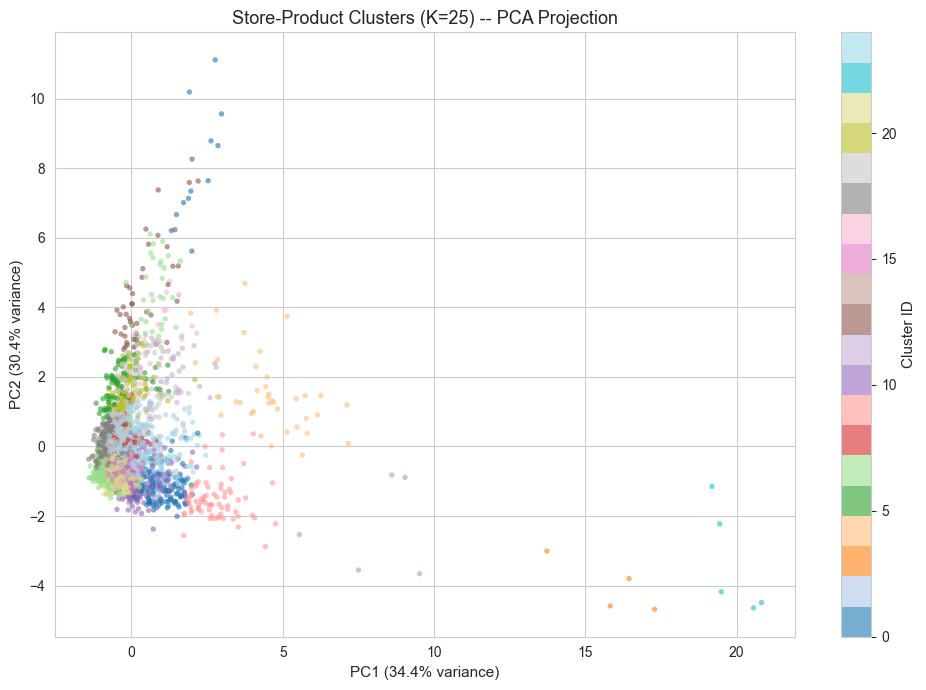

PCA explained variance: 64.8% with 2 components


In [21]:
# ── Visualize clusters in 2D using PCA ──────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=sp_profiles['cluster_id'],
    cmap='tab20', s=15, alpha=0.6, edgecolors='none'
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'Store-Product Clusters (K={K}) -- PCA Projection')
plt.colorbar(scatter, ax=ax, label='Cluster ID')
plt.tight_layout()
plt.savefig(os.path.join(NB_OUT, 'nb02_sp_clusters_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}% with 2 components')

In [22]:
# ── Add cluster_id and cluster-level stats as features ──────────────────────
cluster_map = sp_profiles[['sp', 'cluster_id']].copy()
df = df.merge(cluster_map, on='sp', how='left')

# Cluster-level mean and std of sales
df['cluster_mean'] = df.groupby('cluster_id')['sale_amount'].transform('mean').astype('float32')
df['cluster_std']  = df.groupby('cluster_id')['sale_amount'].transform('std').fillna(0).astype('float32')

cluster_features = ['cluster_id', 'cluster_mean', 'cluster_std']
print(f'Cluster features: {cluster_features}')
print(f'\nCluster-level statistics:')
df.groupby('cluster_id')[['cluster_mean', 'cluster_std']].first().round(3).head(10)

Cluster features: ['cluster_id', 'cluster_mean', 'cluster_std']

Cluster-level statistics:


,cluster_mean,cluster_std
cluster_id,,
0,2.192,1.036
1,0.471,0.798
2,0.901,0.685
3,15.968,8.584
4,2.777,2.724
5,0.695,0.701
6,0.738,0.452
7,0.559,0.637
8,0.700,0.595


**How clustering helps the model**: Products in the same cluster share similar demand patterns. The `cluster_mean` and `cluster_std` act as a "prior" -- if a specific SP has noisy or sparse data, the cluster-level statistics provide a stable baseline. The `cluster_id` itself allows the model to learn cluster-specific splits, effectively sharing information across similar SPs.

### 7.5 Conceptual: Hierarchical Reconciliation

When we forecast at multiple levels of a hierarchy (individual SP, store total, category total, city total), the forecasts often **don't add up**. For example, the sum of all SP forecasts for a store might not equal the store-level forecast.

**Hierarchical reconciliation** methods fix this:

| Method | Description | When to Use |
|--------|-------------|-------------|
| **Bottom-Up** | Forecast at the lowest level (SP), aggregate up | When bottom-level data is rich and reliable |
| **Top-Down** | Forecast at the top level, proportionally distribute down | When top-level data is smooth but bottom is noisy |
| **Middle-Out** | Forecast at an intermediate level, reconcile both up and down | When intermediate level has the best signal-to-noise ratio |
| **MinT (Minimum Trace)** | Optimally combine forecasts from ALL levels by minimizing reconciliation error | Best theoretical properties; requires estimating error covariances |

**In this project**: We use a global model that forecasts at the SP level (bottom-up approach). The hierarchical features we just created (category means, store means, etc.) effectively let the model "see" higher-level information without explicit reconciliation.

For production systems with strict consistency requirements (e.g., store-level inventory budgets must match the sum of SP orders), reconciliation methods like MinT from the `hierarchicalforecast` library are recommended.

---
## 8. Feature Summary

Let us now count all features, examine the most correlated ones with the target, and get a preview of feature importance.

In [23]:
# ── Fill NaN values (from early-window lags/rolling) ─────────────────────────
df = df.fillna(0)

# ── Define feature columns (exclude identifiers and targets) ─────────────────
exclude_cols = {'dt', 'sale_amount', 'dem_rec', 'sp', 'cens', 'so_frac'}
feature_cols = [c for c in df.columns if c not in exclude_cols]

print(f'Total feature count: {len(feature_cols)}')
print(f'Dataset shape: {df.shape}')
print(f'Memory usage: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f'\nFeature groups:')
print(f'  Temporal:             {len(temporal_features)}')
print(f'  Lag:                  {len(lag_features)}')
print(f'  Momentum:             {len(momentum_features)}')
print(f'  Rolling/EWMA:         {len(all_rolling)}')
print(f'  Quantile:             {len(quantile_features)}')
print(f'  Stockout history:     {len(stockout_features)}')
print(f'  Cross/Interaction:    {len(cross_features)}')
print(f'  Hierarchy (agg):      {len(hierarchy_features)}')
print(f'  Relative positioning: {len(relative_features)}')
print(f'  Store-level:          {len(store_features)}')
print(f'  Cluster:              {len(cluster_features)}')
print(f'  Original columns:     (city_id, store_id, product_id, category IDs, discount, etc.)')

Total feature count: 119
Dataset shape: (270000, 125)
Memory usage: 131.5 MB

Feature groups:
  Temporal:             11
  Lag:                  16
  Momentum:             3
  Rolling/EWMA:         36
  Quantile:             4
  Stockout history:     8
  Cross/Interaction:    6
  Hierarchy (agg):      14
  Relative positioning: 5
  Store-level:          2
  Cluster:              3
  Original columns:     (city_id, store_id, product_id, category IDs, discount, etc.)


In [24]:
# ── Top correlated features with the target ─────────────────────────────────
# Use a subset for speed (last 30 days, enough for stable correlations)
recent = df[df['dt'] >= df['dt'].max() - pd.Timedelta(days=30)].copy()

correlations = recent[feature_cols + ['sale_amount']].corr()['sale_amount'].drop('sale_amount')
correlations = correlations.dropna().sort_values(ascending=False)

top_n = 30
top_pos = correlations.head(top_n)
top_neg = correlations.tail(10)

print(f'Top {top_n} positively correlated features:')
for feat, corr in top_pos.items():
    print(f'  {feat:30s}  {corr:+.4f}')

print(f'\nTop 10 negatively correlated features:')
for feat, corr in top_neg.items():
    print(f'  {feat:30s}  {corr:+.4f}')

Top 30 positively correlated features:
  s_rmean7                        +0.9347
  s_ewma14                        +0.9329
  s_ewma7                         +0.9327
  s_rmean14                       +0.9318
  s_rmed7                         +0.9306
  s_q25_14                        +0.9265
  s_rmed28                        +0.9250
  s_rmean28                       +0.9226
  s_q75_14                        +0.9223
  s_q25_28                        +0.9212
  r_rmed28                        +0.9202
  s_rmean3                        +0.9199
  r_rmed7                         +0.9164
  s_q75_28                        +0.9156
  r_rmin7                         +0.9139
  r_rmean14                       +0.9115
  r_ewma14                        +0.9113
  r_rmean7                        +0.9087
  s_lag1                          +0.9047
  r_ewma7                         +0.9035
  s_lag7                          +0.9026
  r_rmean28                       +0.9023
  sp_mean                         +0.

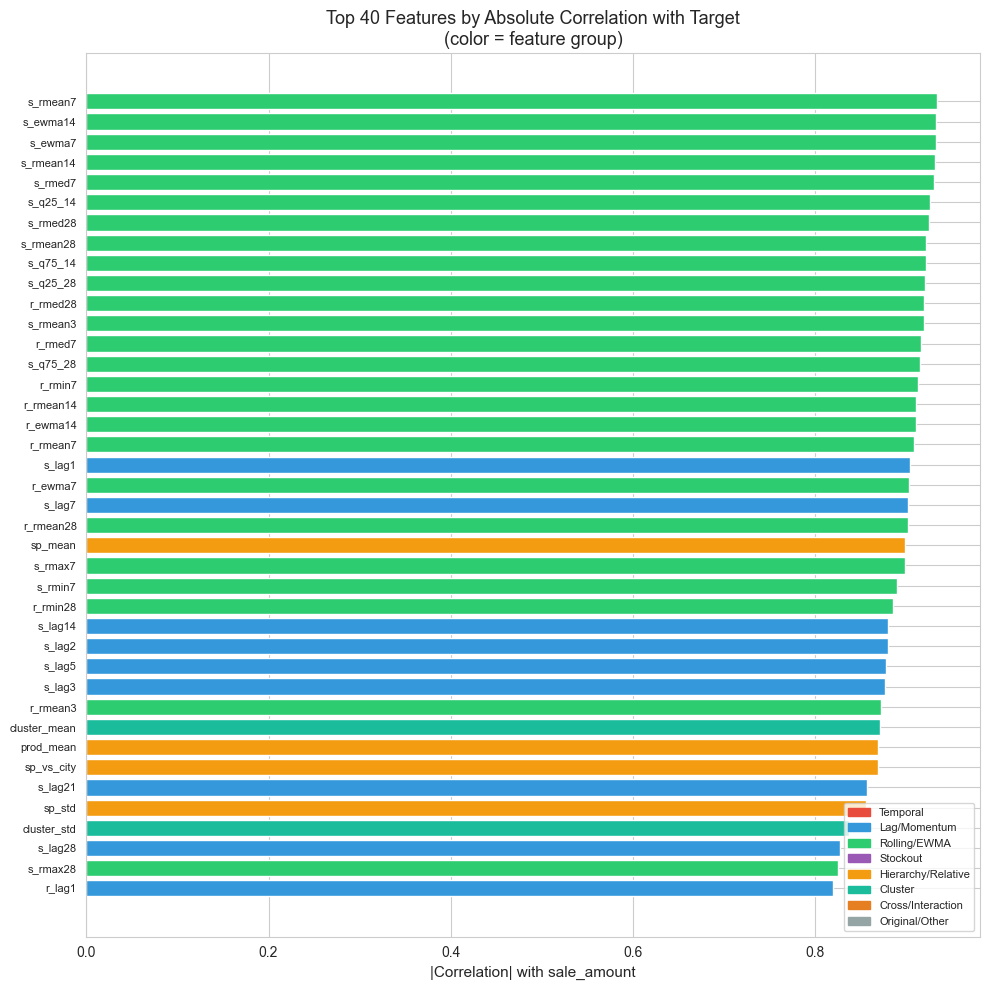

In [25]:
# ── Feature Importance Preview (correlation-based) ──────────────────────────
top_40 = correlations.abs().sort_values(ascending=False).head(40)

fig, ax = plt.subplots(figsize=(10, 10))
colors = []
for f in top_40.index:
    if f in temporal_features: colors.append('#e74c3c')
    elif f in lag_features or f in momentum_features: colors.append('#3498db')
    elif f in all_rolling: colors.append('#2ecc71')
    elif f in stockout_features: colors.append('#9b59b6')
    elif f in hierarchy_features or f in relative_features: colors.append('#f39c12')
    elif f in cluster_features: colors.append('#1abc9c')
    elif f in cross_features: colors.append('#e67e22')
    else: colors.append('#95a5a6')

ax.barh(range(len(top_40)), top_40.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(top_40)))
ax.set_yticklabels(top_40.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('|Correlation| with sale_amount')
ax.set_title('Top 40 Features by Absolute Correlation with Target\n(color = feature group)')

# Legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(color='#e74c3c', label='Temporal'),
    Patch(color='#3498db', label='Lag/Momentum'),
    Patch(color='#2ecc71', label='Rolling/EWMA'),
    Patch(color='#9b59b6', label='Stockout'),
    Patch(color='#f39c12', label='Hierarchy/Relative'),
    Patch(color='#1abc9c', label='Cluster'),
    Patch(color='#e67e22', label='Cross/Interaction'),
    Patch(color='#95a5a6', label='Original/Other'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(NB_OUT, 'nb02_feature_correlation_top40.png'), dpi=150, bbox_inches='tight')
plt.show()
top_40.reset_index().to_csv(os.path.join(NB_OUT, 'nb02_feature_correlation_summary.csv'), index=False)
print(f'Saved nb02_feature_correlation_summary.csv to {NB_OUT}')

### Summary

We have built a comprehensive feature engineering pipeline with approximately **125 features** across 8 groups:

| Group | Count | Key Insight |
|-------|-------|-------------|
| Temporal | 11 | Captures weekly/monthly seasonality; cyclical encoding preserves day adjacency |
| Lag | 16 | Yesterday's and last week's sales are the strongest individual predictors |
| Momentum | 3 | Day-over-day and week-over-week changes capture recent trend direction |
| Rolling/EWMA | ~30 | Smooth summaries of recent demand; EWMA reacts faster to recent shifts |
| Stockout History | 8 | Recent stockout patterns help predict post-stockout demand behavior |
| Cross/Interaction | 6 | Combined effects (discount on holiday) that the model might struggle to learn alone |
| Hierarchy | ~22 | Category/store/city averages + relative positioning -- essential for cold-start |
| Cluster | 3 | Groups similar SPs to borrow strength; cluster-level stats as priors |

**Next steps**: These features feed into a LightGBM model (or any gradient-boosted tree). The lag/rolling features are the workhorses, but hierarchy and cluster features are critical for:
- New products with limited history
- Intermittent-demand products with high noise
- Store-level effects (foot traffic, location quality)

See **Notebook 03** for model training and evaluation.

In [26]:
print('Notebook 02 complete.')
print(f'Final dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Feature columns: {len(feature_cols)}')
print(f'Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')

Notebook 02 complete.
Final dataset: 270,000 rows x 125 columns
Feature columns: 119
Memory: 131.5 MB
